In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# =========================================================
# 1. Carregamento dos dados
# =========================================================

data = load_breast_cancer()
X = data.data
y = data.target

# df = pd.DataFrame(data=data, columns=data.feature_names)
# (0, 30) --> deu ruim

In [3]:
df = pd.DataFrame(data=X, columns=data.feature_names)
df['target'] = y
df.shape

(569, 31)

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
### Holdout unico

In [7]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [8]:
y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)
print(f'A acurácia é: {acc_score}')

A acurácia é: 0.9210526315789473


In [9]:
### Holdout de 3 vias

In [10]:
test_size = 0.15
validation_size = 0.15
validation_size_adjusted = validation_size / (1 - test_size) # 0.17647

In [11]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=validation_size_adjusted, random_state=42, stratify=y_temp
)

In [12]:
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
   dt = DecisionTreeClassifier(max_depth=d, random_state=42)
   dt.fit(X_train, y_train)
   train_score = accuracy_score(y_train, dt.predict(X_train))
   val_score = accuracy_score(y_val, dt.predict(X_val))

   train_scores.append(train_score)
   val_scores.append(val_score)

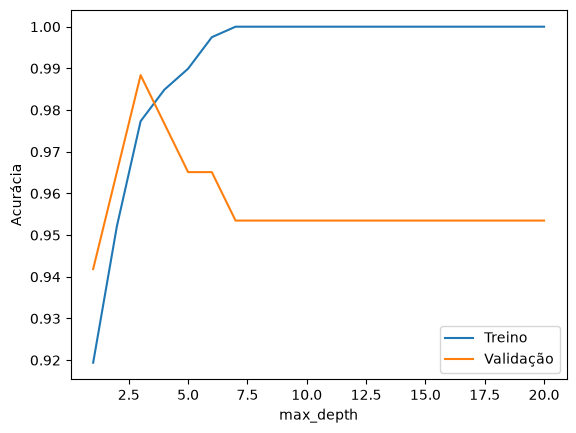

In [13]:
plt.plot(depths, train_scores, label='Treino')
plt.plot(depths, val_scores, label='Validação')
plt.xlabel('max_depth')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

In [14]:
best_depth = max(depths, key=lambda d: val_scores[depths.index(d)])
best_score = max(val_scores)

print(f"Melhor profundidade: {best_depth}")
print(f'Melhor val_score: {best_score}')

Melhor profundidade: 3
Melhor val_score: 0.9883720930232558


### Agora fazendo o certo

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

#### Mas primeiro o errado

In [16]:
X_train, X_test, y_train ,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

scores = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred)
}


df_score = pd.DataFrame.from_dict(scores, orient='index', columns=['score'])
df_score


,score
accuracy,0.947368
precision,0.945205
recall,0.971831
f1_score,0.958333


### Agora certo com cross-validation

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = [ 'accuracy', 'precision', 'recall', 'f1' ]
scores = cross_validate(dt, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)

#print(scores)

df_score = pd.DataFrame(scores)
df_score

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.002771,0.004511,0.967033,0.980769,0.966102,0.978355,0.982759,0.991228,0.974359,0.984749
1,0.007125,0.014633,0.923077,0.975275,0.903226,0.966102,0.982456,0.995633,0.941176,0.980645
2,0.002772,0.004838,0.901099,0.980769,0.944444,0.978448,0.894737,0.991266,0.918919,0.984816
3,0.002992,0.005299,0.956044,0.975275,0.964912,0.974138,0.964912,0.986900,0.964912,0.980477
4,0.003029,0.004442,0.912088,0.980769,0.915254,0.982609,0.947368,0.986900,0.931034,0.984749


### Agora mais certo ainda com nested cross validation (para otimizar os hiperparâmetros)

In [18]:
nc_dt = DecisionTreeClassifier(random_state=42)

# laços internos e externos para repetição de validação cruzada
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



In [19]:
#laço interno para otimização de hiperparâmetro
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [3, 6, 9]
}

grid_search = GridSearchCV(estimator=nc_dt, param_grid=param_grid, cv=inner_cv, scoring='f1', refit=True, n_jobs=-1)

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = [ 'accuracy', 'precision', 'recall', 'f1' ]
scores = cross_validate(dt, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)

#print(scores)

df_score = pd.DataFrame(scores)
df_score

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.004316,0.006184,0.967033,0.980769,0.966102,0.978355,0.982759,0.991228,0.974359,0.984749
1,0.002872,0.004517,0.923077,0.975275,0.903226,0.966102,0.982456,0.995633,0.941176,0.980645
2,0.002554,0.004350,0.901099,0.980769,0.944444,0.978448,0.894737,0.991266,0.918919,0.984816
3,0.002681,0.004205,0.956044,0.975275,0.964912,0.974138,0.964912,0.986900,0.964912,0.980477
4,0.002768,0.004202,0.912088,0.980769,0.915254,0.982609,0.947368,0.986900,0.931034,0.984749


In [22]:
# laço externo para cross validation
scoring_metrics = [ 'accuracy', 'precision', 'recall', 'f1' ]
nested_cv_results = cross_validate(estimator=grid_search, X=X, y=y, cv=outer_cv, scoring=scoring_metrics, return_train_score=False)
print(nested_cv_results)

{'fit_time': array([2.76845551, 0.18035769, 0.16548634, 0.17149758, 0.18030882]), 'score_time': array([0.00746512, 0.00488853, 0.00505567, 0.00538468, 0.00470829]), 'test_accuracy': array([0.95614035, 0.88596491, 0.88596491, 0.94736842, 0.9380531 ]), 'test_precision': array([0.97142857, 0.89189189, 0.89333333, 0.98529412, 0.92105263]), 'test_recall': array([0.95774648, 0.92957746, 0.93055556, 0.93055556, 0.98591549]), 'test_f1': array([0.96453901, 0.91034483, 0.91156463, 0.95714286, 0.95238095])}


In [23]:
results_summary = {}
for metric in scoring_metrics:
    scores = nested_cv_results[f'test_{metric}']
    print(scores)
    results_summary[metric] = {
        'Média': np.mean(scores),
        'Desvio Padrão': np.std(scores)
    }

[0.95614035 0.88596491 0.88596491 0.94736842 0.9380531 ]
[0.97142857 0.89189189 0.89333333 0.98529412 0.92105263]
[0.95774648 0.92957746 0.93055556 0.93055556 0.98591549]
[0.96453901 0.91034483 0.91156463 0.95714286 0.95238095]


In [24]:
df_results = pd.DataFrame(results_summary).T
print(df_results)

              Média  Desvio Padrão
accuracy   0.922698       0.030533
precision  0.932600       0.039030
recall     0.946870       0.022245
f1         0.939194       0.023384


In [25]:
results_dict = {}
for metric, values in nested_cv_results.items():
    if metric.startswith('test_'):
        #print(metric)
        results_dict[metric] = values

print(results_dict)

{'test_accuracy': array([0.95614035, 0.88596491, 0.88596491, 0.94736842, 0.9380531 ]), 'test_precision': array([0.97142857, 0.89189189, 0.89333333, 0.98529412, 0.92105263]), 'test_recall': array([0.95774648, 0.92957746, 0.93055556, 0.93055556, 0.98591549]), 'test_f1': array([0.96453901, 0.91034483, 0.91156463, 0.95714286, 0.95238095])}


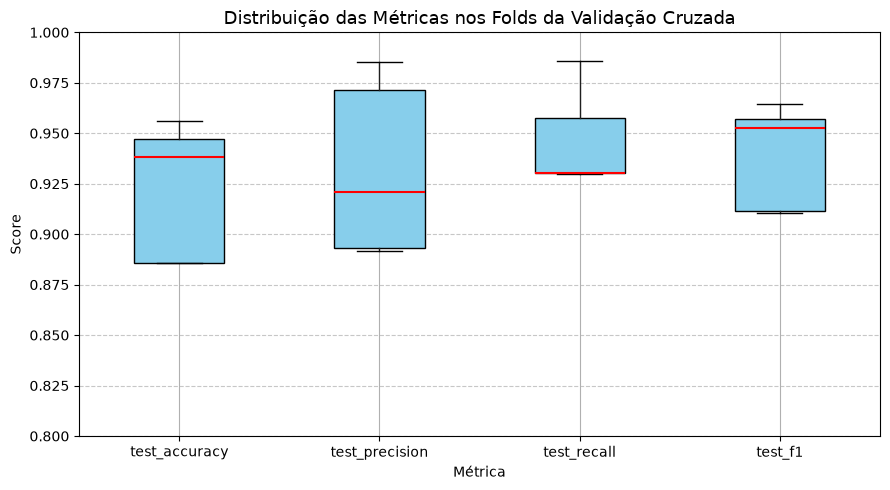

In [26]:
df_results_plot = pd.DataFrame(results_dict)

plt.figure(figsize=(9,5))
df_results_plot.boxplot(patch_artist=True, boxprops=dict(facecolor='skyblue', color='black'), medianprops=dict(color='red', linewidth=1.5))

plt.title("Distribuição das Métricas nos Folds da Validação Cruzada", fontsize=13)
plt.ylabel("Score")
plt.xlabel("Métrica")
plt.ylim(0.8, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Final

Agora que vimos que os resultados estão bons, podemos treinar o modelo final

In [27]:
final_grid = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=inner_cv, scoring='f1')
final_grid.fit(X, y)
print(final_grid)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, None],
                         'min_samples_split': [3, 6, 9]},
             scoring='f1')


In [29]:
final_model = final_grid.best_estimator_
print(final_model)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_split=3,
                       random_state=42)


### Epílogo

In [33]:
data = load_breast_cancer()
X = data.data
y = data.target


### Holdout 80% 20%
X_train, X_test, y_train ,y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

### laços internos e externos para repetição de validação cruzada
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### hiperparâmetros a ser otimizados
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [3, 6, 9]
}

### modelo
dt = DecisionTreeClassifier(random_state=42)

### grid search
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=inner_cv, scoring='f1', refit=True, n_jobs=-1)

### métricas
scoring = [ 'accuracy', 'precision', 'recall', 'f1' ]

### treino
nested_cv_results = cross_validate(estimator=grid_search, X=X, y=y, cv=outer_cv, scoring=scoring_metrics, return_train_score=False)


### vendo os resultados
results_summary = {}
for metric in scoring_metrics:
    scores = nested_cv_results[f'test_{metric}']
    results_summary[metric] = {
        'Média': np.mean(scores),
        'Desvio Padrão': np.std(scores)
    }

df_results = pd.DataFrame(results_summary).T
print(df_results)

              Média  Desvio Padrão
accuracy   0.922698       0.030533
precision  0.932600       0.039030
recall     0.946870       0.022245
f1         0.939194       0.023384
